# 01 — Synthetic walkthrough

Generate a blackbody + power-law background, inject a laser line, and confirm the Loeb–Turner score lights up on the anomalous case.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from anomalymetric.ingest.synthetic import synthetic_natural, synthetic_with_exotic
from anomalymetric.models.powerlaw import PowerLaw
from anomalymetric.models.thermal import BlackBody
from anomalymetric.score.loeb_turner import loeb_turner_score
from anomalymetric.units import wavelength_nm_to_ev

base = synthetic_natural(log_e_min=-2, log_e_max=4, bins_per_decade=40, T_K=300., exposure_cm2_s=1e6, seed=0)
line_eV = float(wavelength_nm_to_ev(532.))
anom = synthetic_with_exotic(base, line_E_eV=line_eV, line_amplitude=5e3, sigma_dex=0.005, seed=1)
print(f'Injected line at {line_eV:.3f} eV')

Injected line at 2.331 eV


Text(0.5, 1.0, 'Synthetic photon spectra')

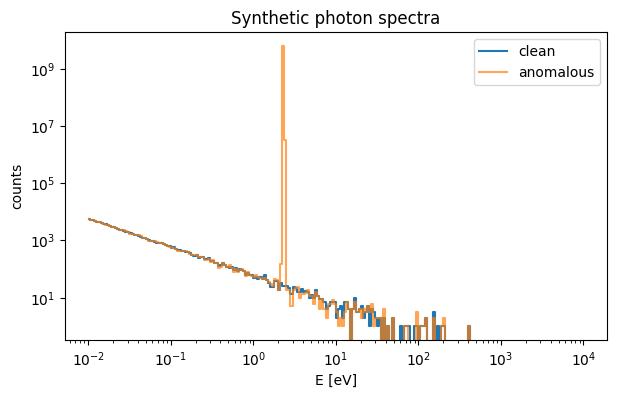

In [2]:
fig, ax = plt.subplots(figsize=(7,4))
c = base.energy_centers_eV
ax.step(c, base.value, where='mid', label='clean')
ax.step(c, anom.value, where='mid', label='anomalous', alpha=0.7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('E [eV]'); ax.set_ylabel('counts')
ax.legend(); ax.set_title('Synthetic photon spectra')

In [3]:
def natural():
    return [BlackBody(T_K=300., amplitude=1.), PowerLaw(amplitude=1e-3, index=2., reference_eV=1.)]

bg_score = loeb_turner_score(base, natural())
anom_score = loeb_turner_score(anom, natural())
print('clean    TS=%.2f  score=%.2f  best=%s' % (bg_score.test_statistic, bg_score.anomaly_score, bg_score.best_template))
print('anomaly  TS=%.2f  score=%.2f  best=%s' % (anom_score.test_statistic, anom_score.anomaly_score, anom_score.best_template))
assert anom_score.test_statistic > bg_score.test_statistic

clean    TS=2.22  score=0.24  best=laser.HeNe_633
anomaly  TS=66056628705.46  score=300.00  best=laser.Nd_YAG_532
